# 機械学習 基礎 — インタラクティブノートブック

scikit-learn を使って回帰・分類・評価・可視化を学びます。  
依存: `pip install scikit-learn matplotlib seaborn`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

np.random.seed(42)
print("準備完了 ✅")

準備完了 ✅


## 1. 線形回帰

RMSE: 15.493
R²  : 0.7986


/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 24112 (\N{CJK UNIFIED IDEOGRAPH-5E30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/3267480219.py:23: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED 

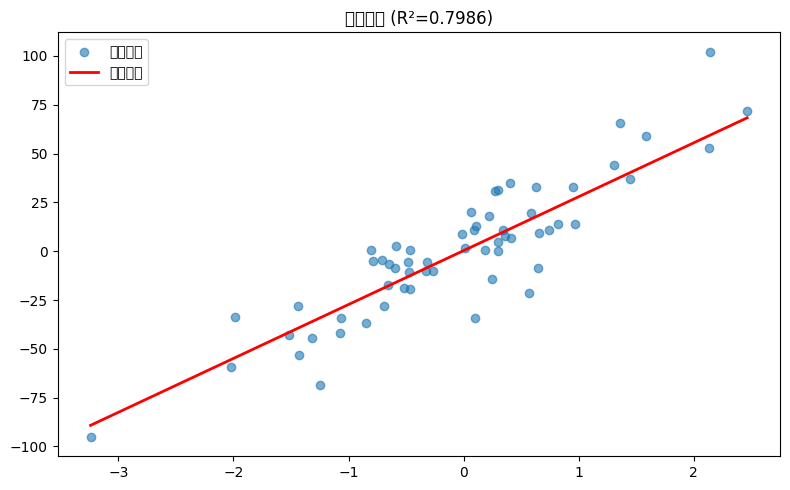

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

X, y = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.6, label="実データ")
x_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color="red", lw=2, label="予測直線")
plt.legend()
plt.title(f"線形回帰 (R²={r2:.4f})")
plt.tight_layout()
plt.show()

## 2. 分類（ロジスティック回帰 vs ランダムフォレスト）

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

cancer = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42)

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, clf in models.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    print(f"\n{'='*40}")
    print(f"モデル: {name}")
    print(f"  Accuracy : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_te, y_pred):.4f}")
    print(f"  F1       : {f1_score(y_te, y_pred):.4f}")


モデル: LogisticRegression
  Accuracy : 0.9737
  Precision: 0.9722
  Recall   : 0.9859
  F1       : 0.9790

モデル: RandomForest
  Accuracy : 0.9649
  Precision: 0.9589
  Recall   : 0.9859
  F1       : 0.9722


/home/abemc/project_root/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24746 (\N{CJK UNIFIED IDEOGRAPH-60AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/abemc/project_root/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/abemc/project_root/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_21052/2788598890.py:13: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/2788598890.py:13: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/2788598890.py:13: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s)

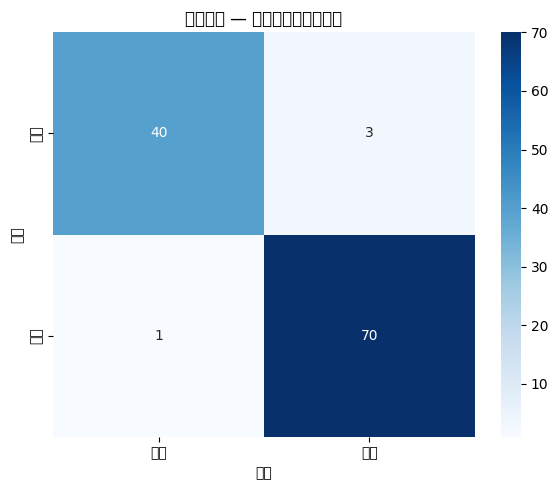

In [4]:
# 混同行列の可視化
rf = models["RandomForest"]
y_pred_rf = rf.predict(X_te)
cm = confusion_matrix(y_te, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["悪性", "良性"],
            yticklabels=["悪性", "良性"])
plt.xlabel("予測")
plt.ylabel("正解")
plt.title("混同行列 — ランダムフォレスト")
plt.tight_layout()
plt.show()

## 3. 交差検証とハイパーパラメータ探索

In [5]:
from sklearn.model_selection import GridSearchCV

iris = load_iris()

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
gs.fit(iris.data, iris.target)

print("最良パラメータ:", gs.best_params_)
print(f"CV 最良スコア: {gs.best_score_:.4f}")

最良パラメータ: {'max_depth': None, 'n_estimators': 50}
CV 最良スコア: 0.9667


## 4. 特徴量重要度

/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21052/221868848.py:12: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missin

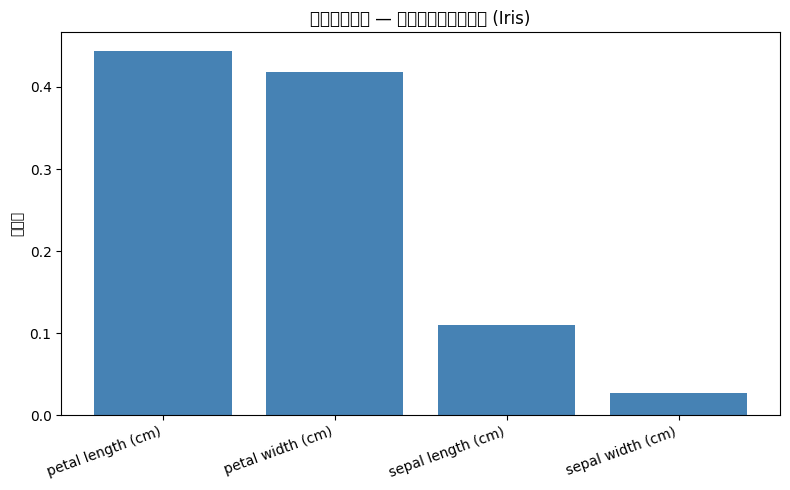

In [6]:
best_rf = gs.best_estimator_
importances = best_rf.feature_importances_
names = iris.feature_names

idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(names)), importances[idx], color="steelblue")
plt.xticks(range(len(names)), [names[i] for i in idx], rotation=20, ha="right")
plt.ylabel("重要度")
plt.title("特徴量重要度 — ランダムフォレスト (Iris)")
plt.tight_layout()
plt.show()